<h1> Objectif du jour:<br>
Savoir lire, écrire et manipuler des fichiers CSV, JSON, Excel et gérer les erreurs proprement</h1>

<h2 style="color: red; text-align: center;">Lecture et écriture de fichiers CSV et Excel</h2>

   <h3 style="color: blue; text-align: center;"> Créer et sauvegarder un fichier CSV</h3>

In [2]:
import pandas as pd
import numpy as np
import json
import os

# Créer un dataset
np.random.seed(42)
df = pd.DataFrame({
    "client_id": range(1, 21),
    "nom": [f"Client_{i}" for i in range(1, 21)],
    "ville": np.random.choice(["Douala", "Yaoundé", "Bafoussam", "Garoua"], 20),
    "montant": np.random.randint(10000, 500000, 20),
    "date": pd.date_range(start="2024-01-01", periods=20, freq="W")
})

# Sauvegarder en CSV
df.to_csv("datasets/clients.csv", index=False)
print("✅ Fichier CSV sauvegardé !")

# Vérifier que le fichier existe
print("Fichier existe :", os.path.exists("datasets/clients.csv"))
print("Taille :", os.path.getsize("datasets/clients.csv"), "bytes")

✅ Fichier CSV sauvegardé !
Fichier existe : True
Taille : 824 bytes


<p> <b>index=False</b> — par défaut Pandas ajoute une colonne d'index (0, 1, 2...) dans le CSV. index=False l'évite — c'est presque toujours ce qu'on veut !</p>

<h3 style="color: blue; text-align: center;"> Lire un fichier CSV avec différentes options :</h3>

In [3]:
# Lecture simple
df_lu = pd.read_csv("datasets/clients.csv")
print("=== LECTURE SIMPLE ===")
print(df_lu.head())
print("Shape :", df_lu.shape)

# Lire avec des options avancées
df_options = pd.read_csv(
    "datasets/clients.csv",
    usecols=["nom", "ville", "montant"],  # lire seulement ces colonnes
    nrows=10,                              # lire seulement 10 lignes
)
print("\n=== LECTURE AVEC OPTIONS ===")
print(df_options)

# Vérifier les types après lecture
print("\n=== TYPES DES COLONNES ===")
print(df_lu.dtypes)

# Convertir la date en datetime
df_lu["date"] = pd.to_datetime(df_lu["date"])
print("\nAprès conversion date :")
print(df_lu.dtypes)

=== LECTURE SIMPLE ===
   client_id       nom      ville  montant        date
0          1  Client_1  Bafoussam   339365  2024-01-07
1          2  Client_2     Garoua    74820  2024-01-14
2          3  Client_3     Douala   272913  2024-01-21
3          4  Client_4  Bafoussam   331879  2024-01-28
4          5  Client_5  Bafoussam   204027  2024-02-04
Shape : (20, 5)

=== LECTURE AVEC OPTIONS ===
         nom      ville  montant
0   Client_1  Bafoussam   339365
1   Client_2     Garoua    74820
2   Client_3     Douala   272913
3   Client_4  Bafoussam   331879
4   Client_5  Bafoussam   204027
5   Client_6     Garoua   337069
6   Client_7     Douala   262709
7   Client_8     Douala   209041
8   Client_9  Bafoussam   277455
9  Client_10    Yaoundé   113355

=== TYPES DES COLONNES ===
client_id    int64
nom            str
ville          str
montant      int64
date           str
dtype: object

Après conversion date :
client_id             int64
nom                     str
ville               

<p> <b style="color: red;">usecols et nrows</b> sont très utiles quand tu travailles avec des fichiers très volumineux — inutile de charger 10 millions de lignes en mémoire si tu n'en as besoin que de 1000 ! C'est une bonne pratique en data science.</p>

<h3 style="color: blue; text-align: center;">  Lecture et écriture de fichiers Excel :</h3> 

In [9]:
# Sauvegarder en Excel avec plusieurs feuilles
with pd.ExcelWriter("datasets/rapport.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Clients", index=False)
    
    # Créer un résumé par ville
    resume = df.groupby("ville")["montant"].agg(["sum", "mean", "count"]).round(0)
    resume.to_excel(writer, sheet_name="Resume_ville")
    
    # Créer un top 5
    top5 = df.nlargest(5, "montant")[["nom", "ville", "montant"]]
    top5.to_excel(writer, sheet_name="Top5_clients", index=False)

print("✅ Fichier Excel sauvegardé avec 3 feuilles !")

# Lire une feuille spécifique
df_excel = pd.read_excel("datasets/rapport.xlsx", sheet_name="Clients")
print("\n=== LECTURE FEUILLE CLIENTS ===")
print(df_excel.head())

# Lire toutes les feuilles
toutes_feuilles = pd.read_excel("datasets/rapport.xlsx", sheet_name=None)
print("\n=== FEUILLES DISPONIBLES ===")
print(list(toutes_feuilles.keys()))
#display("\n test ",toutes_feuilles)

✅ Fichier Excel sauvegardé avec 3 feuilles !

=== LECTURE FEUILLE CLIENTS ===
   client_id       nom      ville  montant       date
0          1  Client_1  Bafoussam   339365 2024-01-07
1          2  Client_2     Garoua    74820 2024-01-14
2          3  Client_3     Douala   272913 2024-01-21
3          4  Client_4  Bafoussam   331879 2024-01-28
4          5  Client_5  Bafoussam   204027 2024-02-04

=== FEUILLES DISPONIBLES ===
['Clients', 'Resume_ville', 'Top5_clients']


<p> <b style="color: red;" >💡 ExcelWriter</b> permet de créer un fichier Excel avec plusieurs feuilles en une seule fois — très utile pour les rapports business ! Le with garantit que le fichier est bien fermé après écriture.</P>

<h3 style="color: blue; text-align: center;">Lire des fichiers CSV depuis internet :</h3> 

In [13]:
# Lire directement depuis une URL
url_titanic = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_titanic = pd.read_csv(url_titanic)
print("=== TITANIC DEPUIS INTERNET ===")
print(df_titanic.shape)
display(df_titanic.head(3))

# Sauvegarder localement pour ne plus avoir besoin d'internet
df_titanic.to_csv("datasets/titanic.csv", index=False)
print("\n✅ Titanic sauvegardé localement !")

# Lire plusieurs fichiers CSV et les combiner
df1 = df_titanic[df_titanic["Pclass"] == 1]
df2 = df_titanic[df_titanic["Pclass"] == 2]
df3 = df_titanic[df_titanic["Pclass"] == 3]

# Sauvegarder séparément
df1.to_csv("datasets/classe1.csv", index=False)
df2.to_csv("datasets/classe2.csv", index=False)
df3.to_csv("datasets/classe3.csv", index=False)

# Recombiner tous les fichiers
import glob
fichiers = glob.glob("datasets/classe*.csv")
df_combine = pd.concat([pd.read_csv(f) for f in fichiers])
print("\n=== FICHIERS COMBINÉS ===")
display(f"Fichiers trouvés : {fichiers}")
print(f"Shape combiné : {df_combine.shape}")

=== TITANIC DEPUIS INTERNET ===
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S



✅ Titanic sauvegardé localement !

=== FICHIERS COMBINÉS ===


"Fichiers trouvés : ['datasets\\\\classe1.csv', 'datasets\\\\classe2.csv', 'datasets\\\\classe3.csv']"

Shape combiné : (891, 12)


<p> <b style="color: red;" >💡 glob </b> permet de trouver tous les fichiers qui correspondent à un pattern — ici tous les fichiers qui commencent par classe et finissent par .csv. C'est très utile quand tu as des dizaines de fichiers à combiner !</p>

<h2 style="color: red; text-align: center;"> JSON ET APIs :</h2>

<h3 style="color: blue; text-align: center;">Manipuler des fichiers JSON :</h3> 

In [14]:
# Créer un dictionnaire Python
data_json = {
    "entreprise": "DataStartup Cameroun",
    "ville": "Douala",
    "fondateur": {
        "nom": "Barthelemy",
        "role": "Data Scientist",
        "competences": ["Python", "Pandas", "NumPy", "ML"]
    },
    "clients": [
        {"id": 1, "nom": "Alice", "montant": 150000},
        {"id": 2, "nom": "Bob", "montant": 230000},
        {"id": 3, "nom": "Carol", "montant": 89000}
    ],
    "chiffre_affaires": 1250000
}

# Sauvegarder en JSON
with open("datasets/startup.json", "w", encoding="utf-8") as f:
    json.dump(data_json, f, ensure_ascii=False, indent=4)
print("✅ Fichier JSON sauvegardé !")

# Lire le fichier JSON
with open("datasets/startup.json", "r", encoding="utf-8") as f:
    data_lu = json.load(f)

print("\n=== DONNÉES LUES ===")
print(f"Entreprise : {data_lu['entreprise']}")
print(f"Fondateur : {data_lu['fondateur']['nom']}")
print(f"Compétences : {data_lu['fondateur']['competences']}")
print(f"Nombre de clients : {len(data_lu['clients'])}")

# Convertir la liste clients en DataFrame
df_clients_json = pd.DataFrame(data_lu["clients"])
print("\n=== CLIENTS EN DATAFRAME ===")
display(df_clients_json)

✅ Fichier JSON sauvegardé !

=== DONNÉES LUES ===
Entreprise : DataStartup Cameroun
Fondateur : Barthelemy
Compétences : ['Python', 'Pandas', 'NumPy', 'ML']
Nombre de clients : 3

=== CLIENTS EN DATAFRAME ===


,id,nom,montant
0,1,Alice,150000
1,2,Bob,230000
2,3,Carol,89000


<p> <b style="color: red;" >JSON </b>est le format le plus utilisé pour échanger des données entre applications — toutes les APIs web retournent du JSON. Savoir le manipuler est indispensable pour un data scientist !</p> 

<h3 style="color: blue; text-align: center;">Appeler une vraie API :</h3> 

In [15]:
import requests

# Appeler une API publique et gratuite — taux de change
url = "https://api.exchangerate-api.com/v4/latest/USD"

response = requests.get(url)
print("Statut de la réponse :", response.status_code)

# Convertir la réponse en JSON
data = response.json()

print(f"\nDate de mise à jour : {data['date']}")
print(f"Devise de base : {data['base']}")

# Extraire les taux qui nous intéressent
devises = ["EUR", "XAF", "GBP", "JPY", "CAD"]
print("\n=== TAUX DE CHANGE (1 USD = ) ===")
for devise in devises:
    print(f"  {devise} : {data['rates'][devise]}")

# Convertir en DataFrame
df_taux = pd.DataFrame(
    list(data["rates"].items()),
    columns=["devise", "taux"]
)
print(f"\nNombre de devises disponibles : {len(df_taux)}")
print(df_taux.head(10))

# Sauvegarder
df_taux.to_csv("datasets/taux_change.csv", index=False)
print("\n✅ Taux de change sauvegardés !")

Statut de la réponse : 200

Date de mise à jour : 2026-04-01
Devise de base : USD

=== TAUX DE CHANGE (1 USD = ) ===
  EUR : 0.867
  XAF : 568.54
  GBP : 0.756
  JPY : 159
  CAD : 1.39

Nombre de devises disponibles : 166
  devise     taux
0    USD     1.00
1    AED     3.67
2    AFN    64.09
3    ALL    83.64
4    AMD   377.46
5    ANG     1.79
6    AOA   922.97
7    ARS  1382.76
8    AUD     1.45
9    AWG     1.79

✅ Taux de change sauvegardés !


<p> <b style="color: red;">💡 requests.get(url)</b> envoie une requête HTTP à une API et récupère la réponse. Le status code 200 signifie que tout s'est bien passé. C'est comme ça que les applications récupèrent des données en temps réel — météo, cours de bourse, taux de change...</p>

<h3 style="color: blue; text-align: center;">Appeler une API avec paramètres :</h3> 

In [17]:
# API d'informations sur les pays — gratuite et sans clé
url = "https://restcountries.com/v3.1/region/africa"

response = requests.get(url)
print("Statut :", response.status_code)

pays_afrique = response.json()
print(f"Nombre de pays africains : {len(pays_afrique)}")

# Extraire les informations utiles
data_pays = []
for pays in pays_afrique:
    data_pays.append({
        "nom": pays["name"]["common"],
        "capitale": pays.get("capital", ["N/A"])[0],
        "population": pays.get("population", 0),
        "superficie": pays.get("area", 0),
        "langue": list(pays.get("languages", {"N/A": "N/A"}).values())[0]
    })

df_pays = pd.DataFrame(data_pays)

# Trier par population
df_pays = df_pays.sort_values("population", ascending=False).reset_index(drop=True)

print("\n=== TOP 10 PAYS AFRICAINS PAR POPULATION ===")
print(df_pays.head(10))

# Trouver le Cameroun
cameroun = df_pays[df_pays["nom"] == "Cameroon"]
print("\n=== CAMEROUN ===")
print(cameroun)

# Sauvegarder
df_pays.to_csv("datasets/pays_afrique.csv", index=False)
print("\n✅ Données pays africains sauvegardées !")

# Trouver le rang du Cameroun
rang = df_pays[df_pays["nom"] == "Cameroon"].index[0] + 1
print(f"Le Cameroun est classé {rang}ème sur {len(df_pays)} pays africains")
print(f"Population : {cameroun['population'].values[0]:,} habitants")
print(f"Superficie : {cameroun['superficie'].values[0]:,} km²")
print(f"Capitale : {cameroun['capitale'].values[0]}")

Statut : 200
Nombre de pays africains : 59

=== TOP 10 PAYS AFRICAINS PAR POPULATION ===
            nom     capitale  population  superficie     langue
0       Nigeria        Abuja   223800000    923768.0    English
1      DR Congo     Kinshasa   112832000   2344858.0     French
2      Ethiopia  Addis Ababa   111652998   1104300.0    Amharic
3         Egypt        Cairo   107271260   1002450.0     Arabic
4      Tanzania       Dodoma    68153004    947303.0    English
5  South Africa     Pretoria    63100945   1221037.0  Afrikaans
6         Kenya      Nairobi    53330978    580367.0    English
7         Sudan     Khartoum    51662000   1886068.0     Arabic
8       Algeria      Algiers    47400000   2381741.0     Arabic
9        Uganda      Kampala    45905417    241550.0    English

=== CAMEROUN ===
         nom capitale  population  superficie   langue
16  Cameroon  Yaoundé    29442327    475442.0  English

✅ Données pays africains sauvegardées !
Le Cameroun est classé 17ème sur 59 pa

<p> <b style="color: red;">💡 pays.get("capital", ["N/A"])[0] </b> — la méthode <b style="color: red;">get() </b>  est plus sûre que <b style="color: red;">pays["capital"]</b>car elle retourne une valeur par défaut si la clé n'existe pas. <br> Certains pays n'ont pas de capitale dans l'API — sans get() ton code planterait !</p>

<h2 style="color: red; text-align: center;"> Gestion des exceptions et logging !</h2>
<h3 style="color: blue; text-align: center;">  Gestion des exceptions (try/except) : </h3>

In [18]:
# Sans gestion d'erreur — le programme plante !
# pd.read_csv("fichier_inexistant.csv")  # ← FileNotFoundError

# Avec gestion d'erreur — le programme continue !
def lire_fichier_csv(chemin):
    try:
        df = pd.read_csv(chemin)
        print(f"✅ Fichier lu avec succès : {df.shape}")
        return df
    except FileNotFoundError:
        print(f"❌ Fichier introuvable : {chemin}")
        return None
    except pd.errors.EmptyDataError:
        print(f"❌ Fichier vide : {chemin}")
        return None
    except Exception as e:
        print(f"❌ Erreur inattendue : {e}")
        return None

# Tests
df1 = lire_fichier_csv("datasets/clients.csv")        # ✅ existe
df2 = lire_fichier_csv("datasets/inexistant.csv")     # ❌ n'existe pas
df3 = lire_fichier_csv("datasets/titanic.csv")        # ✅ existe

✅ Fichier lu avec succès : (20, 5)
❌ Fichier introuvable : datasets/inexistant.csv
✅ Fichier lu avec succès : (891, 12)


<p> <b>try/except </b> est indispensable en production — ton code ne doit jamais planter à cause d'un fichier manquant ou d'une API qui ne répond pas. Un bon data scientist anticipe toujours les erreurs ! 😄</p>

<h3 style="color: blue; text-align: center;"> Logging professionnel : </h3>

In [20]:
import logging

# Forcer l'encodage UTF-8 pour le StreamHandler
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler("datasets/pipeline.log", encoding="utf-8"),
        logging.StreamHandler()
    ]
)

logger = logging.getLogger(__name__)

def pipeline_donnees(chemin_input, chemin_output):
    logger.info(f"Démarrage du pipeline — fichier : {chemin_input}")
    
    try:
        df = pd.read_csv(chemin_input)
        logger.info(f"[OK] Lecture réussie — {df.shape[0]} lignes, {df.shape[1]} colonnes")
    except FileNotFoundError:
        logger.error(f"[ERREUR] Fichier introuvable : {chemin_input}")
        return None
    
    nb_manquants = df.isnull().sum().sum()
    df = df.dropna()
    logger.info(f"[OK] Nettoyage — {nb_manquants} valeurs manquantes supprimées")
    
    if "montant" in df.columns:
        df["montant_normalise"] = (df["montant"] - df["montant"].min()) / \
                                  (df["montant"].max() - df["montant"].min())
        logger.info("[OK] Normalisation du montant effectuée")
    
    df.to_csv(chemin_output, index=False)
    logger.info(f"[OK] Pipeline terminé — fichier sauvegardé : {chemin_output}")
    
    return df

df_propre = pipeline_donnees("datasets/clients.csv", "datasets/clients_propre.csv")

2026-04-01 05:04:07,107 - INFO - Démarrage du pipeline — fichier : datasets/clients.csv
2026-04-01 05:04:07,114 - INFO - [OK] Lecture réussie — 20 lignes, 5 colonnes
2026-04-01 05:04:07,119 - INFO - [OK] Nettoyage — 0 valeurs manquantes supprimées
2026-04-01 05:04:07,125 - INFO - [OK] Normalisation du montant effectuée
2026-04-01 05:04:07,132 - INFO - [OK] Pipeline terminé — fichier sauvegardé : datasets/clients_propre.csv


<h2 style="color: black; text-align: center;">  Exercice pratique !</h2>
<h3 style="color: black; text-align: center;"> Contexte : Tu es data scientist dans une startup fintech camerounaise.<br> Tu dois construire un pipeline complet de données.<h3>

1. Crée et sauvegarde un dataset de 50 transactions bancaires en CSV avec ces colonnes : <br>transaction_id, client, type (Dépôt/Retrait/Virement), montant, ville, date<br>
2. Relis le fichier CSV avec seulement les colonnes client, montant, type<br>
3. Crée un fichier JSON contenant un résumé de la startup :<br>
<ul>
  <li>Nom, ville, fondateur </li>
  <li>Statistiques : nombre de transactions, montant total, montant moyen</li>
  </ul>
4. Appelle l'API https://api.exchangerate-api.com/v4/latest/XAF et convertis les montants de ton dataset en EUR et en USD<br>
5. Construis un pipeline avec logging qui :<br>
<ul>
    <li>Lit le CSV</li>
  <li>Nettoie les données</li>
  <li>Ajoute les colonnes montant_eur et montant_usd</li>
  <li>Sauvegarde le résultat final</li>
</ul>
6. Trace un graphique du montant total par type de transaction

✅ Fichier CSV sauvegardé !
Fichier existe : True
Taille : 2406 bytes

=== LECTURE AVEC OPTIONS ===
       client  montant      type
0    Client_1   249629   Retrait
1    Client_2   215041  Virement
2    Client_3   184073     Depôt
3    Client_4   217624   Retrait
4    Client_5   427113     Depôt
5    Client_6    78148     Depôt
6    Client_7   262801     Depôt
7    Client_8   134243     Depôt
8    Client_9   261995  Virement
9   Client_10   392318     Depôt
10  Client_11   164555     Depôt
11  Client_12   396502     Depôt
12  Client_13    58555  Virement
13  Client_14   266508     Depôt
14  Client_15   289303     Depôt
15  Client_16   382654  Virement
16  Client_17   116530  Virement
17  Client_18    90077  Virement
18  Client_19   308064     Depôt
19  Client_20   495283  Virement
20  Client_21   470337  Virement
21  Client_22   210551     Depôt
22  Client_23   492691  Virement
23  Client_24   291601     Depôt
24  Client_25   469773   Retrait
25  Client_26   218261  Virement
26  Client

{'entreprise': 'DataStartup Cameroun',
 'ville': 'Douala',
 'fondateur': {'nom': 'Barthelemy',
  'role': 'Data Scientist',
  'competences': ['Python', 'Pandas', 'NumPy', 'ML']},
 'stats': [{'nombre_transaction': 50},
  {'montant_total': 13034592},
  {'montant_moyen': 260691.84}]}

Statut de la réponse : 200
     client  montant  montant_eur  montant_usd
0  Client_1   249629       379.44       439.35
1  Client_2   215041       326.86       378.47
2  Client_3   184073       279.79       323.97
3  Client_4   217624       330.79       383.02
4  Client_5   427113       649.21       751.72

Date de mise à jour : 2026-04-01
Devise de base : XAF

=== TAUX DE CHANGE (1 XFA = ) ===
  EUR : 0.00152
  USD : 0.00176

Nombre de devises disponibles : 166
  devise     taux
0    XAF  1.00000
1    AED  0.00646
2    AFN  0.11200
3    ALL  0.14700
4    AMD  0.66000
5    ANG  0.00315
6    AOA  1.65000
7    ARS  2.43000
8    AUD  0.00255
9    AWG  0.00315


['transaction_id',
 'client',
 'ville',
 'montant',
 'type',
 'date',
 'montant_eur',
 'montant_usd']

2026-04-01 16:16:31,770 - INFO - Démarrage du pipeline — fichier : datasets/banque.csv
2026-04-01 16:16:31,777 - INFO - [OK] Lecture réussie — 50 lignes, 6 colonnes
2026-04-01 16:16:31,786 - INFO - [OK] Nettoyage — 0 doublons supprimés
2026-04-01 16:16:31,791 - INFO - [OK] Colonnes montant_eur et montant_usd ajoutées
2026-04-01 16:16:31,806 - INFO - [OK] Pipeline terminé — fichier sauvegardé : datasets/banque_propre.csv


=== MONTANT TOTAL PAR TYPE ===
Depôt : 5,496,849 FCFA
Virement : 5,446,225 FCFA
Retrait : 2,091,518 FCFA


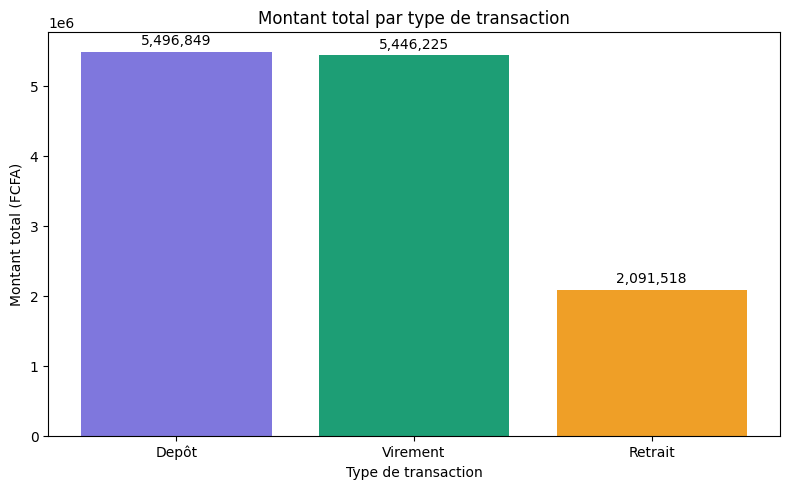

In [65]:
import pandas as pd
import numpy as np
import json
import requests
import logging
import os
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(42)
#1- Crée et sauvegarde un dataset de 50 transactions bancaires en CSV avec ces colonnes :

# Créer un dataset
np.random.seed(42)
df = pd.DataFrame({
    "transaction_id": range(1, 51),
     "client": [f"Client_{i}" for i in range(1, 51)],
    "ville": np.random.choice(["Douala", "Yaoundé", "Bafoussam", "Garoua","Bamenda","Buea"], 50),
    "montant": np.random.randint(10000, 500000, 50),
    "type":np.random.choice(["Depôt", "Retrait", "Virement"], 50),
    "date": pd.date_range(start="2025-01-01", periods=50, freq="W-MON")
})
# Sauvegarder en CSV
df.to_csv("datasets/banque.csv", index=False)
print("✅ Fichier CSV sauvegardé !")

# Vérifier que le fichier existe
print("Fichier existe :", os.path.exists("datasets/banque.csv"))
print("Taille :", os.path.getsize("datasets/banque.csv"), "bytes")

#2- Relis le fichier CSV avec seulement les colonnes client, montant, type
# Lire avec des options avancées
df_options = pd.read_csv(
    "datasets/banque.csv",
    usecols=["client", "montant","type"]  # lire seulement ces colonnes
   
)
print("\n=== LECTURE AVEC OPTIONS ===")
print(df_options)

#3- Crée un fichier JSON contenant un résumé de la startup :
#Nom, ville, fondateur
#Statistiques : nombre de transactions, montant total, montant moyen

# Créer un dictionnaire Python
data_json = {
    "entreprise": "DataStartup Cameroun",
    "ville": "Douala",
    "fondateur": {
        "nom": "Barthelemy",
        "role": "Data Scientist",
        "competences": ["Python", "Pandas", "NumPy", "ML"]
    },
    "stats": [
        {"nombre_transaction": df["transaction_id"].count()},
        {"montant_total":df["montant"].sum()},
        {"montant_moyen":df[ "montant"].mean()}
    ]
   
}
#Fonction magique pour convertir les types spécifiques à Pandas/NumPy
def np_encoder(obj):
    if isinstance(obj, (np.int64, np.int32, np.int16, np.integer)):
        return int(obj)
    if isinstance(obj, (np.float64, np.float32, np.floating)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return str(obj) # Par sécurité, on convertit le reste en texte

#  Sauvegarder en utilisant l'argument 'default'
with open("datasets/startup.json", "w", encoding="utf-8") as f:
    json.dump(data_json, f, ensure_ascii=False, indent=4, default=np_encoder)
print("✅ Fichier JSON sauvegardé sans erreur !")
# lecture du fichier JSON
with open("datasets/startup.json", "r", encoding="utf-8") as f:
    data_lu = json.load(f)
    display(data_lu)

#4. Appelle l'API https://api.exchangerate-api.com/v4/latest/XAF et convertis les montants de ton dataset en EUR et en USD
import requests
# Appeler une API publique et gratuite — taux de change
url = "https://api.exchangerate-api.com/v4/latest/XAF"
response=requests.get(url)
print("Statut de la réponse :", response.status_code)
#convertis les montants de ton dataset en EUR et en USD
taux_eur = data["rates"]["EUR"]
taux_usd = data["rates"]["USD"]

df["montant_eur"] = (df["montant"] * taux_eur).round(2)
df["montant_usd"] = (df["montant"] * taux_usd).round(2)

print(df[["client", "montant", "montant_eur", "montant_usd"]].head())
# Convertir la réponse en JSON
data = response.json()
print(f"\nDate de mise à jour : {data['date']}")
print(f"Devise de base : {data['base']}")

# Extraire les taux qui nous intéressent
devises = ["EUR", "USD"]
print("\n=== TAUX DE CHANGE (1 XFA = ) ===")
for devise in devises:
    print(f"  {devise} : {data['rates'][devise]}")

# Convertir en DataFrame
df_taux = pd.DataFrame(
    list(data["rates"].items()),
    columns=["devise", "taux"]
)
print(f"\nNombre de devises disponibles : {len(df_taux)}")
print(df_taux.head(10))

#5. Construis un pipeline avec logging qui :
display(df.columns.tolist())
#lecture du fichier csv
import logging

# Forcer l'encodage UTF-8 pour le StreamHandler
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler("datasets/pipeline.log", encoding="utf-8"),
        logging.StreamHandler()
    ]
)

logger = logging.getLogger(__name__)

import pandas as pd

def pipeline_donnees(chemin_input, chemin_output):
    logger.info(f"Démarrage du pipeline — fichier : {chemin_input}")
    
    try:
        df = pd.read_csv(chemin_input)
        logger.info(f"[OK] Lecture réussie — {df.shape[0]} lignes, {df.shape[1]} colonnes")
    except FileNotFoundError:
        logger.error(f"[ERREUR] Fichier introuvable : {chemin_input}")
        return None

    # --- TOUT CE QUI SUIT DOIT RESTER ALIGNÉ ICI ---
    
    # Nettoie les données
    nb_doublons = df.duplicated().sum()
    df = df.drop_duplicates()
    
    # Note : Assurez-vous que nb_manquants, taux_eur et taux_usd sont définis 
    # avant ces lignes ou passés en arguments.
    logger.info(f"[OK] Nettoyage — {nb_doublons} doublons supprimés")
    # logger.info(f"[OK] Nettoyage — {nb_manquants} valeurs manquantes supprimées")

    # Ajouter les colonnes EUR et USD dans le pipeline
    df["montant_eur"] = (df["montant"] * taux_eur).round(2)
    df["montant_usd"] = (df["montant"] * taux_usd).round(2)
    logger.info("[OK] Colonnes montant_eur et montant_usd ajoutées")

    # Sauvegarde du fichier
    df.to_csv(chemin_output, index=False)
    logger.info(f"[OK] Pipeline terminé — fichier sauvegardé : {chemin_output}")    
    
    return df

# L'appel de la fonction doit être collé tout à gauche
df_propre = pipeline_donnees("datasets/banque.csv", "datasets/banque_propre.csv")

#6. Trace un graphique du montant total par type de transaction
# Afficher les chiffres exacts
montant_total = df.groupby("type")["montant"].sum().sort_values(ascending=False)
print("=== MONTANT TOTAL PAR TYPE ===")
for type_trans, montant in montant_total.items():
    print(f"{type_trans} : {montant:,} FCFA")

# Ajouter les valeurs sur le graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(montant_total.index, montant_total.values, 
               color=["#7F77DD", "#1D9E75", "#EF9F27"])
# Ajouter les valeurs au dessus de chaque barre
for bar, valeur in zip(bars, montant_total.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
             f"{valeur:,}", ha="center", va="bottom", fontsize=10)

plt.title("Montant total par type de transaction")
plt.xlabel("Type de transaction")
plt.ylabel("Montant total (FCFA)")
plt.tight_layout()
plt.show()



<p> Les Dépôts dominent car c'est la transaction la plus fréquente — les clients déposent régulièrement leur argent. Les Virements suivent car ce sont souvent de gros montants ponctuels. Les Retraits sont généralement plus petits et plus fréquents.</p>